# 01 - EDA : Telecom Churn

| Partie | Question à laquelle on répond |
|---|---|
| **A. Inspection** | Les données sont-elles propres ? |
| **B. Nettoyage** | Que faut-il corriger ? |
| **C. Univarié** | À quoi ressemble chaque variable seule ? |
| **D. Bivarié** | Quelles variables sont liées au churn ? |

Ce notebook est descriptif : rien n'est « appris » sur les données (pas de scaler, pas de SMOTE). Ces étapes viendront après le split train/test, dans des `Pipeline` (J3).

# A. Inspection des données brutes

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

CANDIDATES = [Path("../data/raw/wa-fn-usec-telco-customer-churn.csv"),
              Path("../data/wa-fn-usec-telco-customer-churn.csv")]
RAW_PATH = next((p for p in CANDIDATES if p.exists()), None)
if RAW_PATH is None:
    raise FileNotFoundError("CSV introuvable : vérifie le dossier data/")
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RAW_PATH)
print("Dimensions :", df.shape)
df.info()

Dimensions : (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-nu

**Observation :** 7043 clients, 21 colonnes. `TotalCharges` est de type texte alors que c'est un montant : elle contient forcément des valeurs non numériques.

In [2]:
print("NaN            :", df.isna().sum().sum())
print("Lignes dupliquées :", df.duplicated().sum())
print("customerID dupliqués :", df["customerID"].duplicated().sum())

# Un NaN peut se cacher sous forme d'espace " "
cols_texte = df.select_dtypes(include=["object", "string"]).columns
vides = df[cols_texte].apply(lambda s: s.str.strip().eq("")).sum()
print("\nChaînes vides par colonne :")
print(vides[vides > 0])

NaN            : 0
Lignes dupliquées : 0
customerID dupliqués : 0

Chaînes vides par colonne :
TotalCharges    11
dtype: int64


In [3]:
total_num = pd.to_numeric(df["TotalCharges"], errors="coerce")   # test seulement, df reste intact
df.loc[total_num.isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]]

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**Observation :**
- Aucun NaN, aucun doublon.
- 11 valeurs de `TotalCharges` sont des espaces. Toutes ces lignes ont `tenure = 0` : ce sont des clients arrivés ce mois-ci, pas encore facturés. Leur total réel est donc **0**.

In [4]:
for col in df.select_dtypes(include=["object", "string"]).columns.drop(["customerID", "TotalCharges"]):
    print(f"{col:18s} -> {df[col].unique().tolist()}")

gender             -> ['Female', 'Male']
Partner            -> ['Yes', 'No']
Dependents         -> ['No', 'Yes']
PhoneService       -> ['No', 'Yes']
MultipleLines      -> ['No phone service', 'No', 'Yes']
InternetService    -> ['DSL', 'Fiber optic', 'No']
OnlineSecurity     -> ['No', 'Yes', 'No internet service']
OnlineBackup       -> ['Yes', 'No', 'No internet service']
DeviceProtection   -> ['No', 'Yes', 'No internet service']
TechSupport        -> ['No', 'Yes', 'No internet service']
StreamingTV        -> ['No', 'Yes', 'No internet service']
StreamingMovies    -> ['No', 'Yes', 'No internet service']
Contract           -> ['Month-to-month', 'One year', 'Two year']
PaperlessBilling   -> ['Yes', 'No']
PaymentMethod      -> ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
Churn              -> ['No', 'Yes']


**Observation :** pas de faute de frappe. `No internet service` et `No phone service` répètent l'information de `InternetService` / `PhoneService` (à traiter au Feature Engineering, J3).

# B. Nettoyage

On travaille sur une copie `df_clean` : `df` reste le brut, pour comparer si besoin.

In [ ]:
df_clean = df.copy()

# 1) TotalCharges : espace -> 0, puis conversion en nombre
blank = df_clean["TotalCharges"].str.strip().eq("")
assert (df_clean.loc[blank, "tenure"] == 0).all()     # on vérifie l'hypothèse avant d'imputer
df_clean.loc[blank, "TotalCharges"] = "0"
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"])

# 2) customerID : identifiant unique, sans valeur prédictive
assert df_clean["customerID"].is_unique
df_clean = df_clean.drop(columns="customerID")

# 3) Churn : Yes/No -> 1/0
df_clean["Churn"] = df_clean["Churn"].map({"No": 0, "Yes": 1})
assert df_clean["Churn"].notna().all()

In [6]:
print("Dimensions :", df_clean.shape)
print("NaN        :", df_clean.isna().sum().sum())
print("Lignes identiques (hors ID) :", df_clean.duplicated().sum())
print("Taux de churn :", round(df_clean["Churn"].mean() * 100, 2), "%")

OUT_PATH = PROCESSED_DIR / "telecom_churn_cleaned.csv"
df_clean.to_csv(OUT_PATH, index=False)
print("Sauvegardé :", OUT_PATH)

Dimensions : (7043, 20)
NaN        : 0
Lignes identiques (hors ID) : 22
Taux de churn : 26.54 %
Sauvegardé : ..\data\processed\telecom_churn_cleaned.csv


**Décisions :**
- `TotalCharges` vide → **0** : règle métier (client jamais facturé), pas une statistique calculée sur les données, donc pas de data leakage. La médiane (~1400) serait fausse pour un client neuf.
- `customerID` supprimé : il n'apprend rien au modèle et fausserait le clustering.
- `Churn` en 0/1 : la moyenne de la colonne devient directement le taux de churn.
- **22 lignes identiques** apparaissent une fois l'ID retiré. Ce sont des clients différents avec le même profil (normal avec des variables surtout catégorielles) : on les **garde**.
- Le CSV propre est sauvegardé : les notebooks suivants repartent de lui.

# C. Analyse univariée

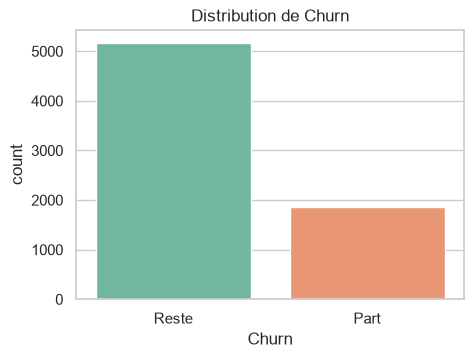

Churn
0    73.5
1    26.5
Name: proportion, dtype: float64


In [7]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in df_clean.columns if c not in num_cols + ["Churn"]]   # 16 colonnes (SeniorCitizen = 0/1)

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.countplot(data=df_clean, x="Churn", hue="Churn", palette="Set2", legend=False, ax=ax)
ax.set_xticks([0, 1], ["Reste", "Part"])
ax.set_title("Distribution de Churn")
plt.show()
print((df_clean["Churn"].value_counts(normalize=True) * 100).round(1))

**Observation :** 73,5 % restent, 26,5 % partent : classes **déséquilibrées**.

**Décision pour la suite :** juger les modèles avec Recall / F1 / ROC-AUC (l'accuracy serait trompeuse), utiliser `stratify` au split, puis `class_weight` ou SMOTE sur le train uniquement.

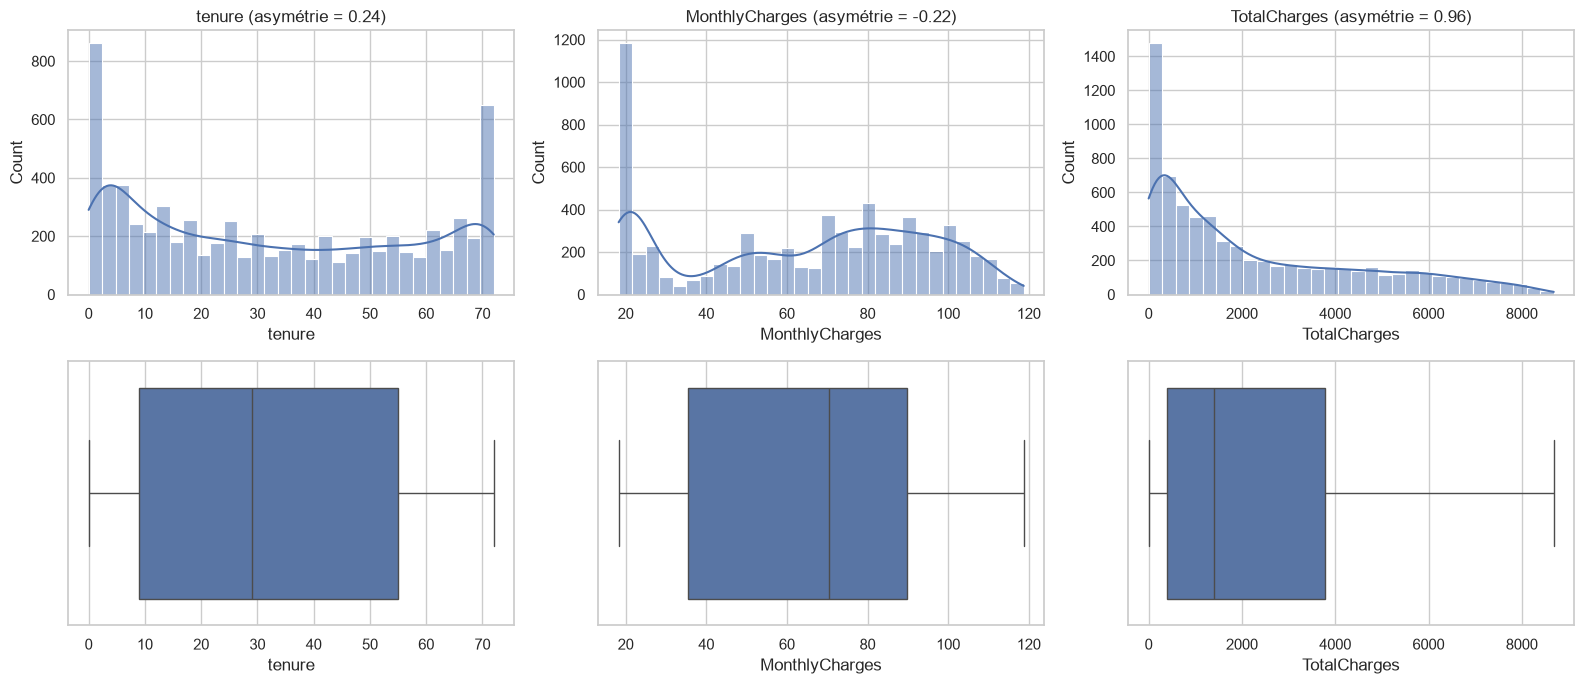

Outliers (règle IQR) : {'tenure': 0, 'MonthlyCharges': 0, 'TotalCharges': 0}


In [8]:
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum())

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
for i, col in enumerate(num_cols):
    sns.histplot(df_clean[col], kde=True, bins=30, ax=axes[0, i])
    axes[0, i].set_title(f"{col} (asymétrie = {df_clean[col].skew():.2f})")
    sns.boxplot(x=df_clean[col], ax=axes[1, i])
plt.tight_layout()
plt.show()
print("Outliers (règle IQR) :", {c: iqr_outliers(df_clean[c]) for c in num_cols})

**Observation :**
- `tenure` : deux pics, un à 1 mois (613 clients) et un à 72 mois (362 clients).
- `MonthlyCharges` : environ 20 % des clients paient moins de 25.
- `TotalCharges` : très étalée vers la droite (c'est un cumul).
- **Outliers : 0** sur les trois variables.

**Décision :** on ne supprime rien. `TotalCharges` étant asymétrique, on la standardisera (voire log) avant K-Means et SVM.

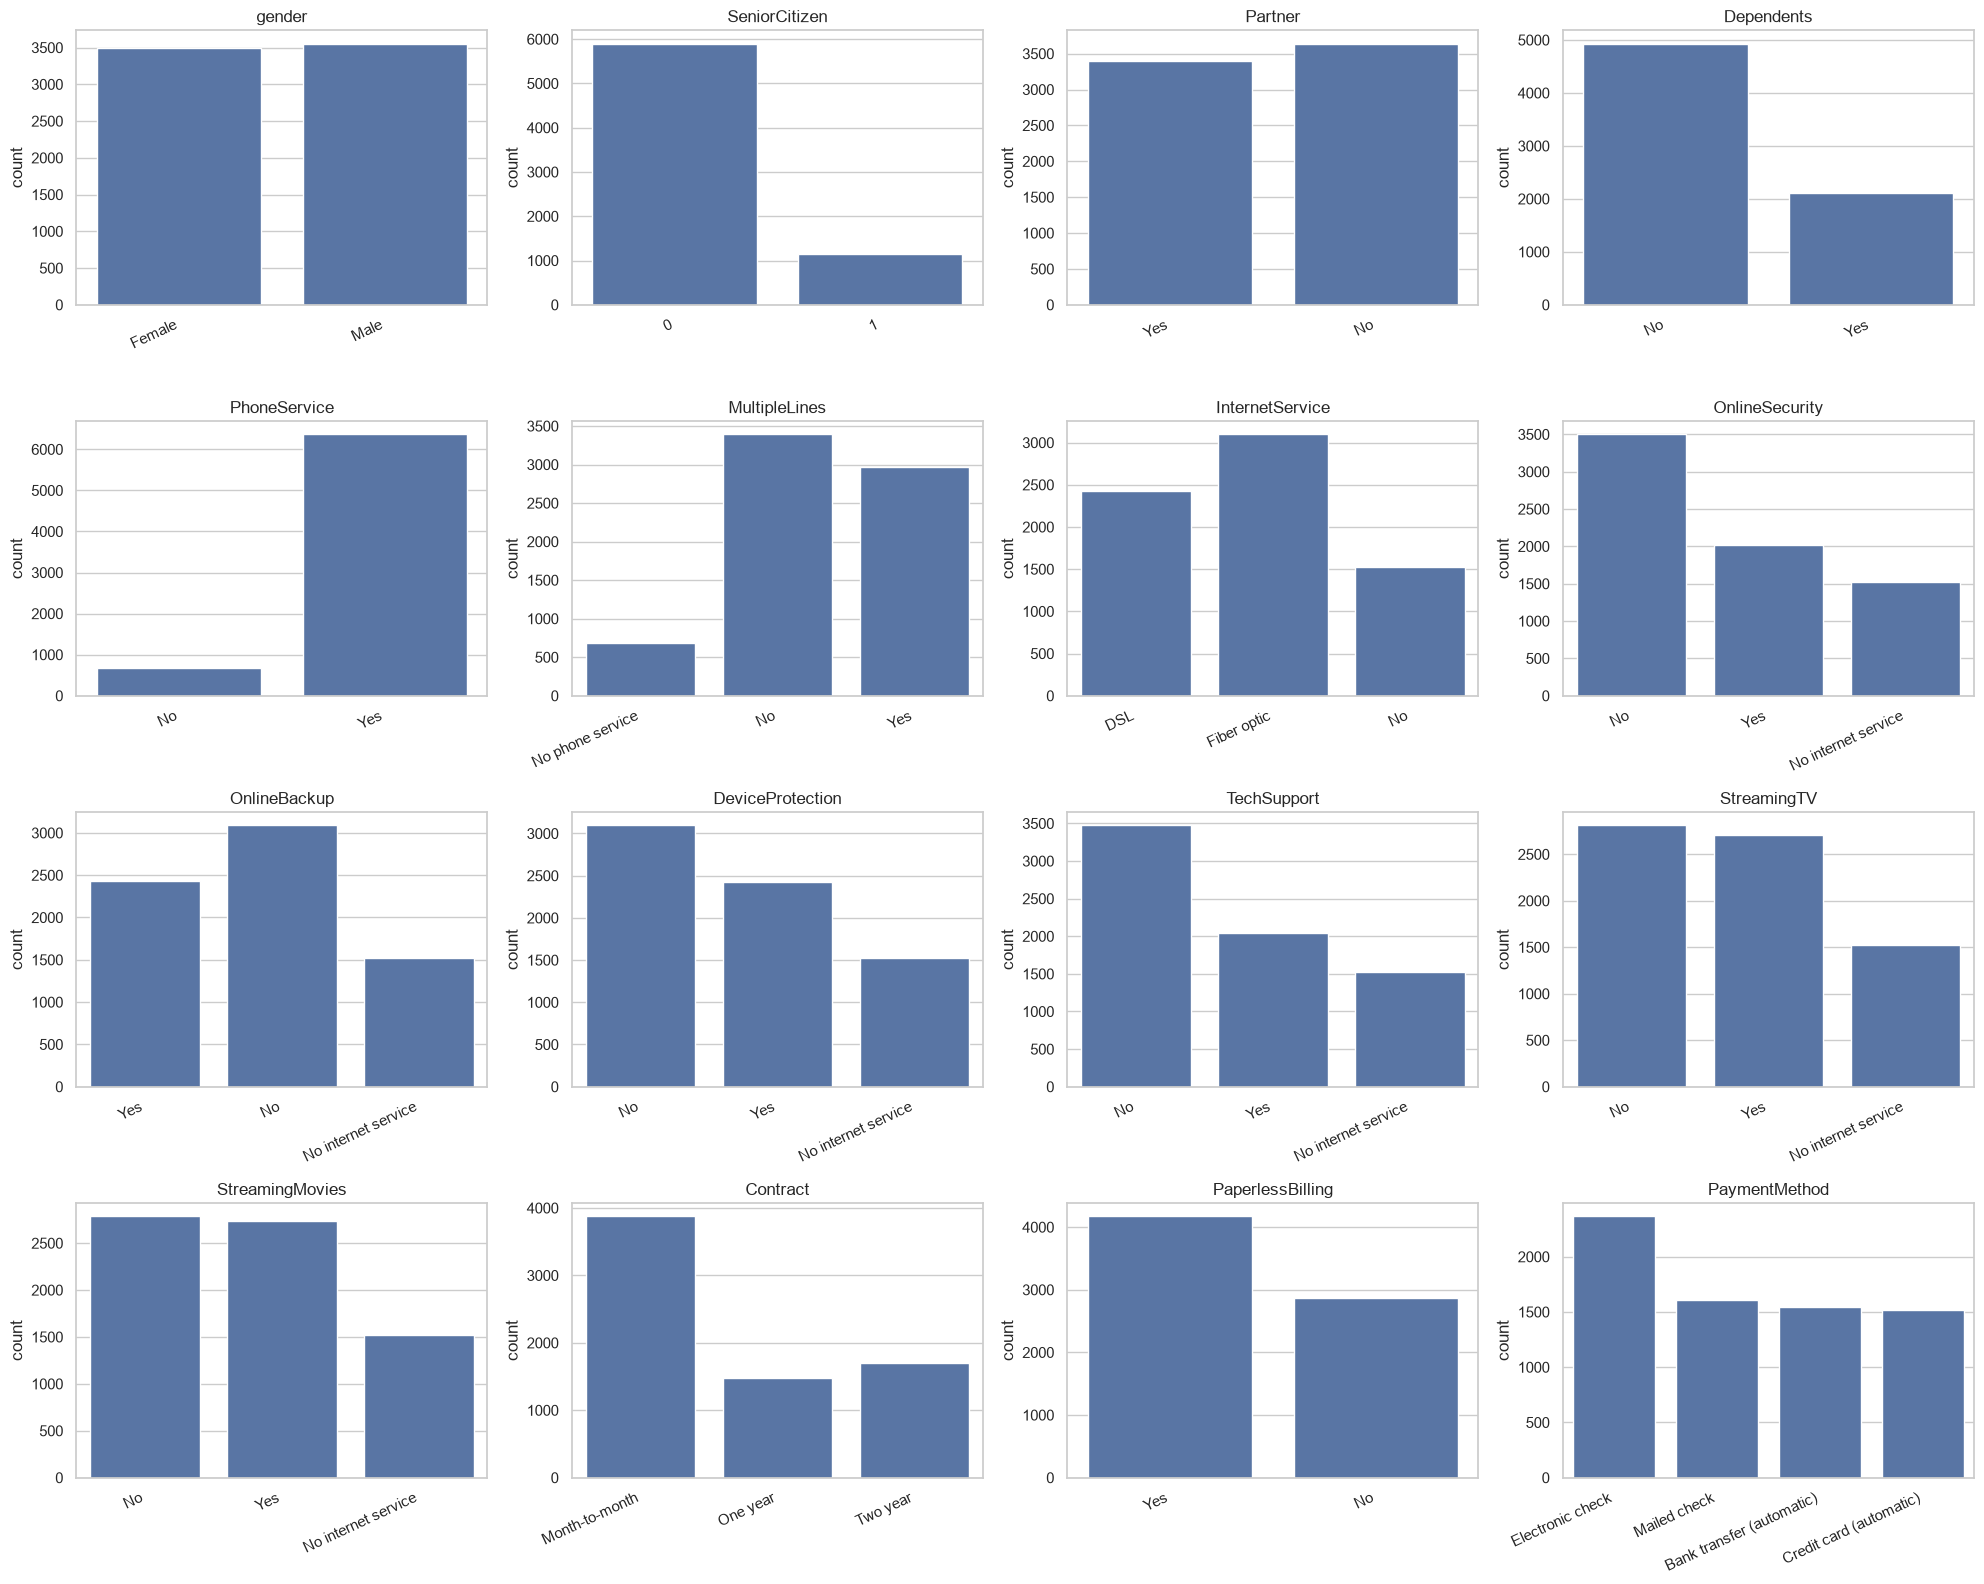

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.countplot(data=df_clean, x=col, color="#4C72B0", ax=ax)
    ax.set_title(col); ax.set_xlabel("")
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.show()

**Observation :** aucune modalité trop rare. `PhoneService` est presque toujours « Yes » (peu informative).

# D. Analyse bivariée : qu'est-ce qui pousse un client à partir ?

On compare le **taux de churn** de chaque groupe au taux global (26,5 %).

,tenure,MonthlyCharges,TotalCharges
Churn,,,
Reste,38.0,64.4,1679.5
Part,10.0,79.6,703.6


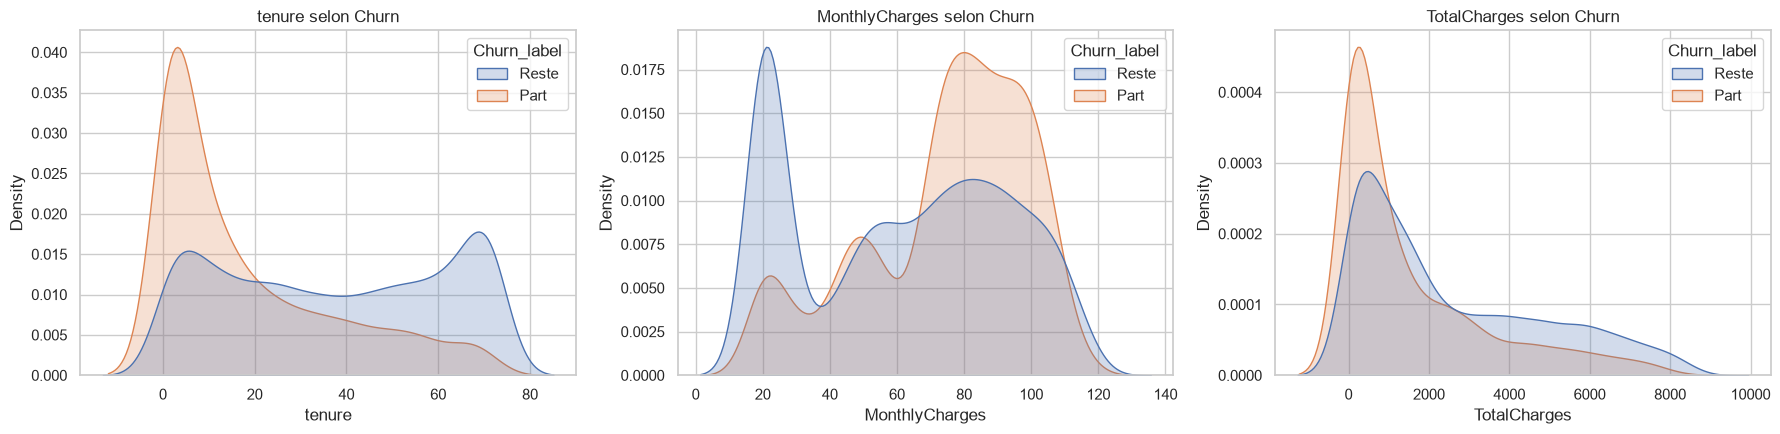

In [10]:
df_eda = df_clean.assign(Churn_label=df_clean["Churn"].map({0: "Reste", 1: "Part"}))
display(df_clean.groupby("Churn")[num_cols].median().round(1).rename(index={0: "Reste", 1: "Part"}))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, col in zip(axes, num_cols):
    sns.kdeplot(data=df_eda, x=col, hue="Churn_label", common_norm=False, fill=True,
                palette={"Reste": "#4C72B0", "Part": "#DD8452"}, ax=ax)
    ax.set_title(f"{col} selon Churn")
plt.tight_layout()
plt.show()

**Observation (valeurs médianes) :**
- `tenure` : **10 mois** chez ceux qui partent contre **38** chez ceux qui restent.
- `MonthlyCharges` : ≈ 80 contre ≈ 64 : les partants paient plus cher.
- `TotalCharges` : plus bas chez les partants, simplement parce qu'ils sont là depuis moins longtemps.

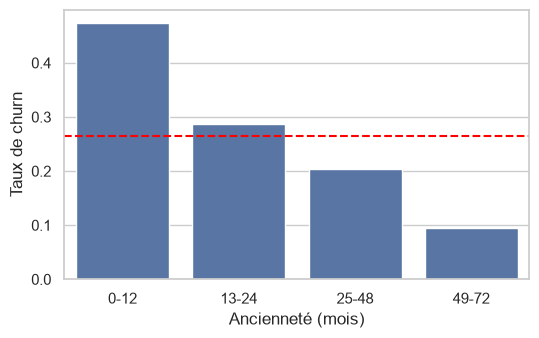

tenure_group
0-12     47.4
13-24    28.7
25-48    20.4
49-72     9.5
Name: Churn, dtype: float64


In [11]:
df_eda["tenure_group"] = pd.cut(df_eda["tenure"], bins=[-1, 12, 24, 48, 72],
                                labels=["0-12", "13-24", "25-48", "49-72"])
rate = df_eda.groupby("tenure_group", observed=True)["Churn"].mean()

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.barplot(x=rate.index.astype(str), y=rate.values, color="#4C72B0", ax=ax)
ax.axhline(df_clean["Churn"].mean(), color="red", ls="--")
ax.set_xlabel("Ancienneté (mois)"); ax.set_ylabel("Taux de churn")
plt.show()
print((rate * 100).round(1))

**Observation :** le churn est de **47 %** la première année et tombe à **9,5 %** après 4 ans. La relation n'est pas une droite : une variable `tenure_group` sera utile (J3).

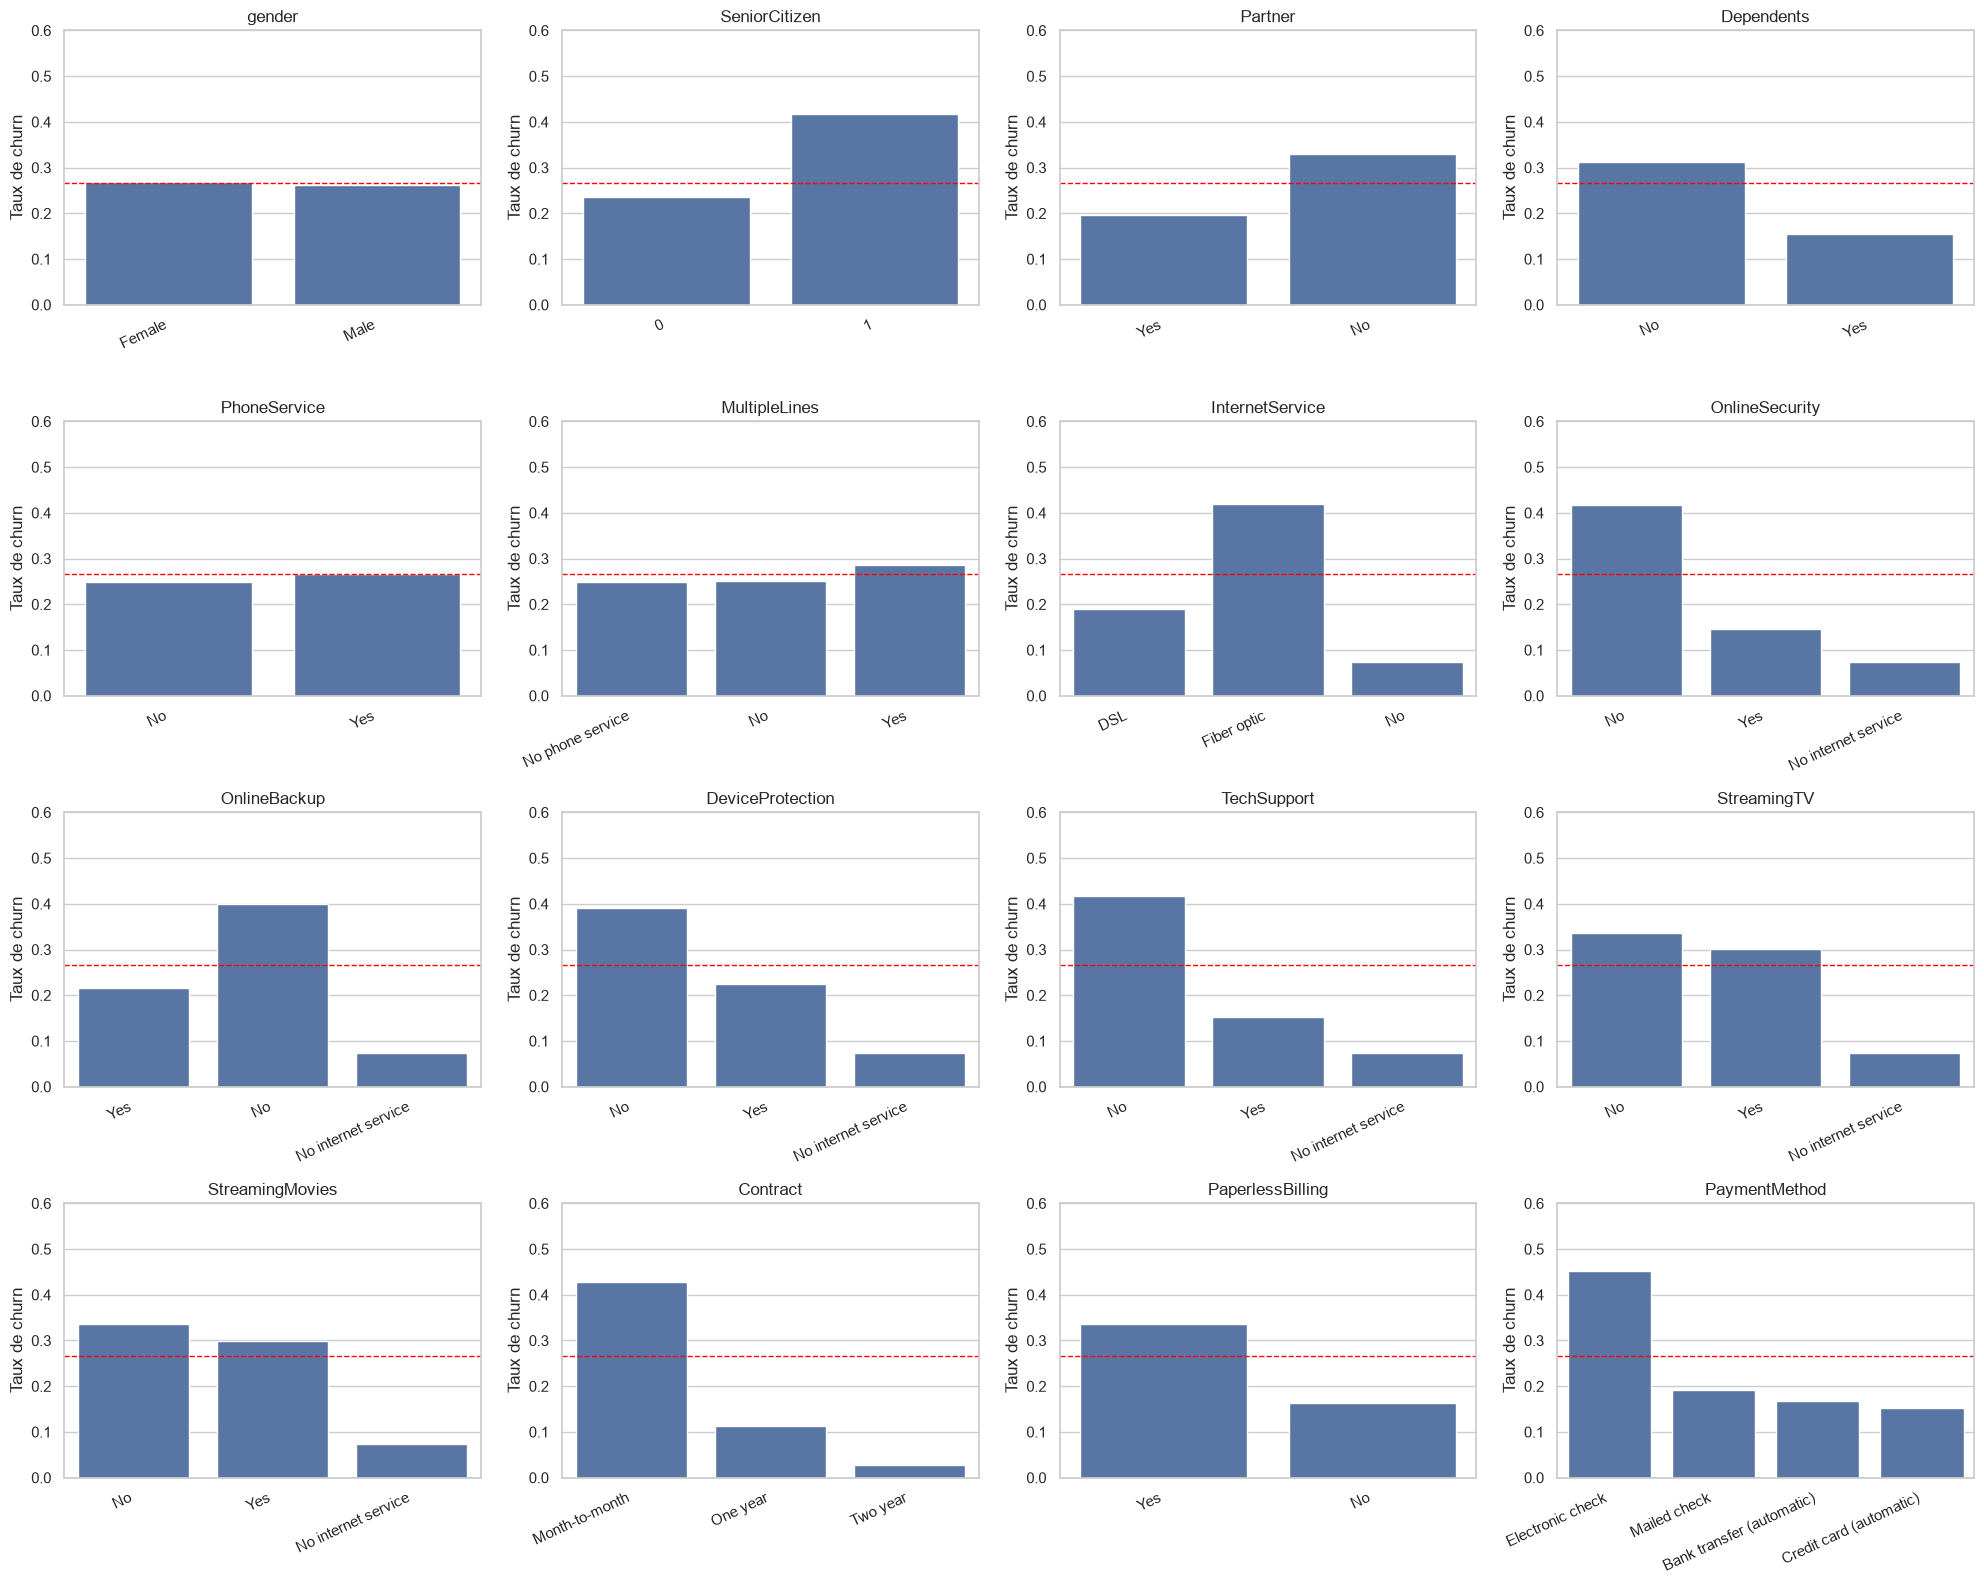

In [ ]:
global_rate = df_clean["Churn"].mean()
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
for ax, col in zip(axes.ravel(), cat_cols):
    sns.barplot(data=df_clean, x=col, y="Churn", errorbar=None, color="#4C72B0", ax=ax)
    ax.axhline(global_rate, color="red", ls="--", lw=1)
    ax.set_ylim(0, 0.6)
    ax.set_title(col); ax.set_xlabel(""); ax.set_ylabel("Taux de churn")
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
plt.tight_layout()
plt.show()

**Observation** (ligne rouge = 26,5 %, une barre au-dessus = groupe à risque) :
- **Contrat** : mensuel 42,7 %, 1 an 11,3 %, 2 ans 2,8 %.
- **Internet** : fibre 41,9 %, DSL 19,0 %, sans internet 7,4 %.
- **Paiement** : chèque électronique 45,3 %, les autres modes 15 à 19 %.
- **Sécurité en ligne / support technique** : sans le service ≈ 42 %, avec ≈ 15 %.
- **Senior** : 41,7 % contre 23,6 %.
- `gender`, `PhoneService`, `MultipleLines` : presque aucune différence entre groupes.

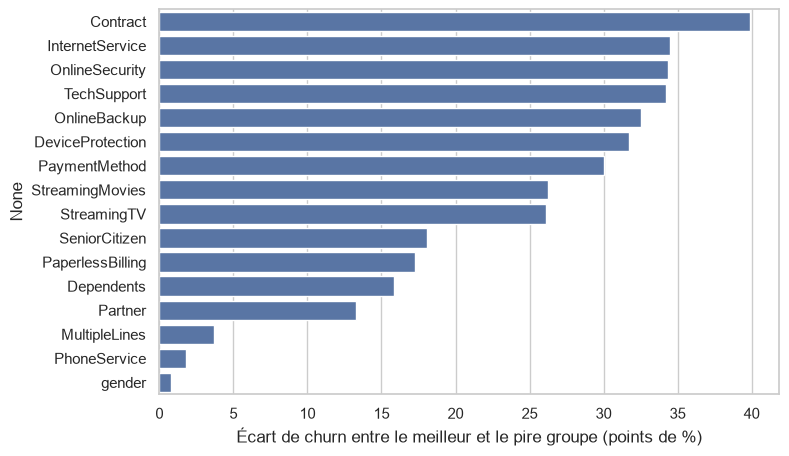

In [13]:
spread = pd.Series({c: df_clean.groupby(c)["Churn"].mean().agg(lambda g: g.max() - g.min())
                    for c in cat_cols}).sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=spread.values, y=spread.index, color="#4C72B0", ax=ax)
ax.set_xlabel("Écart de churn entre le meilleur et le pire groupe (points de %)")
plt.show()

**Comment lire :** pour chaque variable, on prend le groupe qui part le plus et celui qui part le moins, et on regarde l'écart. Plus il est grand, plus la variable sépare les clients fidèles des clients à risque.

**Observation :** `Contract` en tête (≈ 40 points), puis `InternetService`, `OnlineSecurity`, `TechSupport`, `OnlineBackup`, `PaymentMethod`. À l'inverse `gender` (< 1 point) et `PhoneService` n'apportent presque rien.

*Ce classement est un repère, pas une règle de suppression : les modèles trancheront.*

## Corrélations entre variables numériques

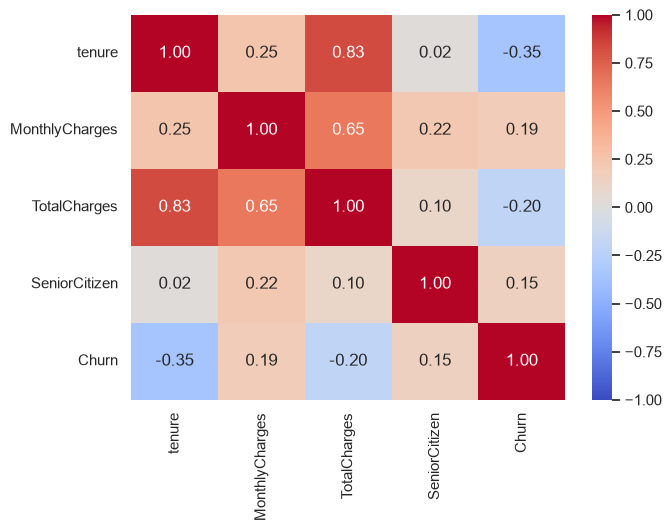

In [14]:
corr = df_clean[["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, center=0, ax=ax)
plt.show()

**Comment lire :** chaque case mesure si deux colonnes évoluent ensemble, de **-1 à +1**.
- **+1** : quand l'une monte, l'autre monte aussi.
- **-1** : quand l'une monte, l'autre descend.
- **0** : aucun lien.

**Observation :**
- `tenure` ↔ `Churn` = **-0,35** : plus un client est ancien, moins il part (le lien le plus net avec la cible).
- `tenure` ↔ `TotalCharges` = **0,83** : ces deux colonnes disent presque la même chose (`TotalCharges` ≈ ancienneté × facture mensuelle).
- `MonthlyCharges` ↔ `Churn` = +0,19 : lien faible.

**Décision :** garder les deux colonnes pour l'instant, mais retenir que `tenure` et `TotalCharges` comptent en double : à surveiller pour le clustering et la régression logistique.

*Une corrélation n'est pas une cause : elle indique un lien, pas pourquoi il existe.*

# Bilan et suite

**Profil du client qui part :** contrat mensuel, ancienneté faible (médiane 10 mois), fibre optique, chèque électronique, sans sécurité en ligne ni support technique, facture mensuelle plus élevée.

**Pistes de Feature Engineering (J3) :**

| Variable à créer | Idée |
|---|---|
| `tenure_group` | Tranches d'ancienneté (relation non linéaire) |
| `n_services` | Nombre de services souscrits |
| `avg_monthly_paid` | `TotalCharges / tenure` (attention à `tenure = 0`) |
| `is_month_to_month` | Contrat mensuel = risque maximal |
| `auto_payment` | Prélèvement automatique ou non |
| Fusion `No internet service` → `No` | Supprimer les modalités redondantes |

**Lexique :** *outlier* = valeur très éloignée des autres · *IQR* = écart entre le 25e et le 75e centile · *corrélation* = lien entre deux colonnes numériques (-1 à +1) · *data leakage* = information du test qui « fuit » dans l'entraînement.